In [18]:
from node_b import NodeB
from numpy.random import default_rng
from slice_l1 import SliceL1eMBB, SliceL1mMTC
from slice_ran import SliceRANeMBB, SliceRANmMTC
from channel_models import SINRSelectiveFading, MCSCodeset
from schedulers import ProportionalFair
from itertools import count
import matplotlib.pyplot as plt


In [19]:
 # Initialize random number generator
rng = default_rng(seed=42)

    # Create basic parameters for slices
CBR_description = {'lambda': 2.0 / 60.0, 't_mean': 30.0, 'bit_rate': 500000}
VBR_description = {'lambda': 5.0 / 60.0, 't_mean': 30.0, 'p_size': 1000, 'b_size': 500, 'b_rate': 1}
SLA_embb = {'cbr_th': 10e6, 'cbr_prb': 20, 'cbr_queue': 10e4, 'vbr_th': 15e6, 'vbr_prb': 30, 'vbr_queue': 15e4}
state_variables_embb = ['cbr_traffic', 'cbr_th', 'cbr_prb', 'cbr_queue', 'cbr_snr', 'vbr_traffic', 'vbr_th',
                            'vbr_prb', 'vbr_queue', 'vbr_snr']
norm_const_embb = {'cbr_traffic': 5e6 * 0.05, 'cbr_th': 10e6 * 0.05, 'cbr_prb': 25 * 50, 'cbr_queue': 10e4 * 50,
                       'cbr_snr': 35 * 50,
                       'vbr_traffic': 5e6 * 0.05, 'vbr_th': 10e6 * 0.05, 'vbr_prb': 35 * 50, 'vbr_queue': 10e4 * 50,
                       'vbr_snr': 35 * 50}

    # Create channel model and scheduler
snr_generator = SINRSelectiveFading(rng, 'macro_cell_urban_2GHz', n_prbs=100)
mcs_codeset = MCSCodeset()
scheduler = ProportionalFair(mcs_codeset)
user_counter = count()

    # Create eMBB slice
slice_ran_embb = SliceRANeMBB(rng, user_counter, 0, SLA_embb, CBR_description, VBR_description,
                                  state_variables_embb, norm_const_embb, 50)
slice_l1_embb = SliceL1eMBB(rng, snr_generator, 50, [slice_ran_embb], scheduler)

    # Create mMTC slice
MTC_description = {'n_devices': 1000, 'repetition_set': [2, 4, 8, 16, 32, 64, 128],
                       'period_set': [1000, 50000, 10000, 15000, 20000, 25000, 50000, 100000]}
state_variables_mmtc = ['devices', 'avg_rep', 'delay']
SLA_mmtc = {'delay': 300}
norm_const_mmtc = {'devices': 100 * 50, 'avg_rep': 100 * 50, 'delay': 100 * 50}
slice_ran_mmtc = SliceRANmMTC(rng, 1, SLA_mmtc, MTC_description, state_variables_mmtc, norm_const_mmtc, 50)
slice_l1_mmtc = SliceL1mMTC(50, [slice_ran_mmtc])

    # Create slices list
my_slices = [slice_l1_embb, slice_l1_mmtc]


In [20]:
# Create a NodeB instance
gnb = NodeB(
    id=1,
    x=100,
    y=100,
    slices_l1=my_slices,
    slots_per_step=10,
    n_prbs=50,
    coverage_radius=500,
    slot_length=1e-3
)

print(f"✓ NodeB created successfully")
print(f"  - ID: {gnb.id}")
print(f"  - Position: ({gnb.x}, {gnb.y})")
print(f"  - Coverage radius: {gnb.coverage_radius}m")
print(f"  - Number of slices: {gnb.n_slices_l1}")
print(f"  - Slots per step: {gnb.slots_per_step}")
print(f"  - Total PRBs: {gnb.n_prbs}")
print(f"  - Slot length: {gnb.slot_length}s")
print(f"  - Coverage area: {gnb.coverage_area:.2f}m²")

# Test vertices calculation
print(f"\n✓ Hexagon vertices:")
for i, vertex in enumerate(gnb.vertices):
    print(f"  Vertex {i+1}: ({vertex[0]:.2f}, {vertex[1]:.2f})")

✓ NodeB created successfully
  - ID: 1
  - Position: (100, 100)
  - Coverage radius: 500m
  - Number of slices: 2
  - Slots per step: 10
  - Total PRBs: 50
  - Slot length: 0.001s
  - Coverage area: 649519.05m²

✓ Hexagon vertices:
  Vertex 1: (600.00, 100.00)
  Vertex 2: (350.00, 533.01)
  Vertex 3: (-150.00, 533.01)
  Vertex 4: (-400.00, 100.00)
  Vertex 5: (-150.00, -333.01)
  Vertex 6: (350.00, -333.01)



SECTION 2: Coverage Testing - Point in Polygon
Testing point coverage:
------------------------------------------------------------
Point                Coordinates     In Coverage  Distance    
------------------------------------------------------------
Center               ( 100,  100)  ✓ YES        0.00m
North edge           ( 100,  500)  ✓ YES        400.00m
South (outside)      ( 100, -300)  ✓ YES        400.00m
East edge            ( 533,  100)  ✓ YES        433.00m
West (outside)       (-333,  100)  ✓ YES        433.00m
Inside (NE quadrant) ( 350,  400)  ✓ YES        390.51m
Inside (SE quadrant) ( 400,  200)  ✓ YES        316.23m
Inside (NW quadrant) ( 200,  400)  ✓ YES        316.23m
Inside (SW quadrant) ( 300,    0)  ✓ YES        223.61m


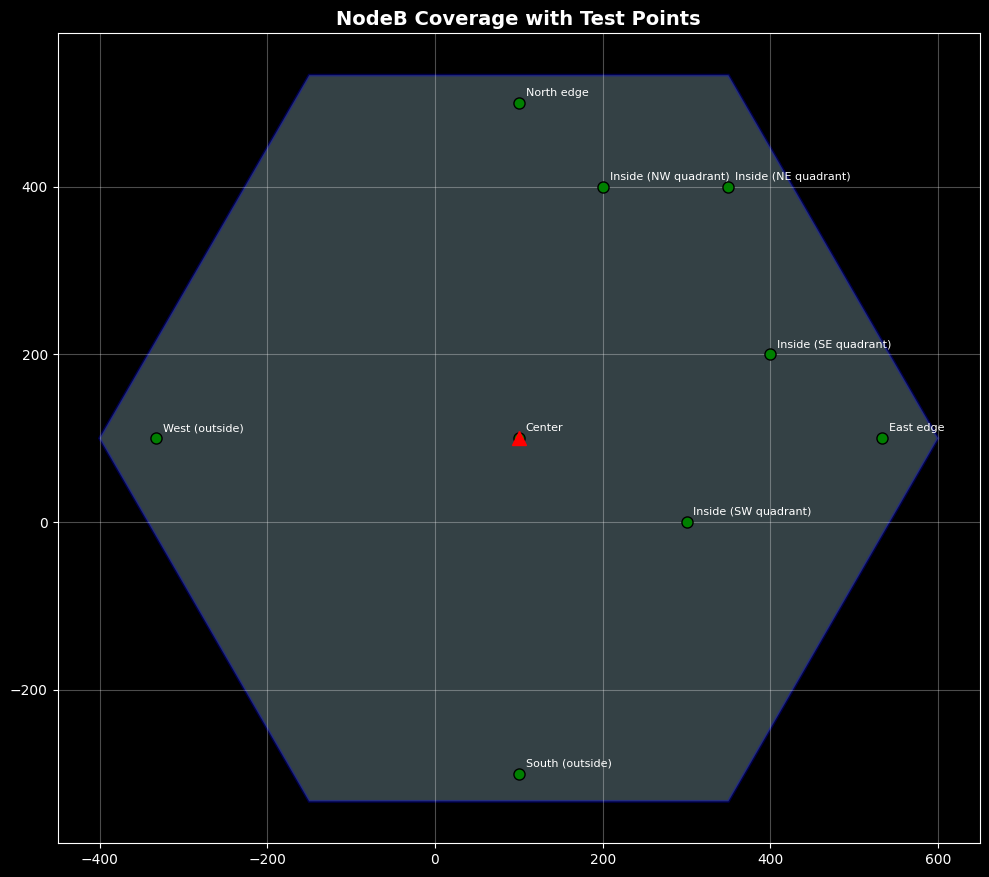

In [9]:
# ============================================
# SECTION 2: Coverage Testing - Point in Polygon
# ============================================

print("\n" + "=" * 80)
print("SECTION 2: Coverage Testing - Point in Polygon")
print("=" * 80)

# Define test points
test_points = [
    (100, 100, "Center"),
    (100, 500, "North edge"),
    (100, -300, "South (outside)"),
    (533, 100, "East edge"),
    (-333, 100, "West (outside)"),
    (350, 400, "Inside (NE quadrant)"),
    (400, 200, "Inside (SE quadrant)"),
    (200, 400, "Inside (NW quadrant)"),
    (300, 0, "Inside (SW quadrant)"),
]

print("Testing point coverage:")
print("-" * 60)
print(f"{'Point':<20} {'Coordinates':<15} {'In Coverage':<12} {'Distance':<12}")
print("-" * 60)

for x, y, desc in test_points:
    in_coverage = gnb.is_point_in_coverage(x, y)
    distance = gnb.distance_to_ue(x, y)
    status = "✓ YES" if in_coverage else "✗ NO"
    print(f"{desc:<20} ({x:>4}, {y:>4})  {status:<12} {distance:.2f}m")

# Visualize coverage with test points
fig, ax = plt.subplots(figsize=(10, 10))
gnb.visualize_coverage(ax=ax, color='lightblue', alpha=0.3, edge_color='blue')

# Plot test points
for x, y, desc in test_points:
    in_coverage = gnb.is_point_in_coverage(x, y)
    color = 'green' if in_coverage else 'red'
    marker = 'o' if in_coverage else 'x'
    ax.plot(x, y, marker, color=color, markersize=8, markeredgecolor='black', markeredgewidth=1)
    ax.annotate(desc, (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_title('NodeB Coverage with Test Points', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


SECTION 3: Signal Strength and SNR Testing


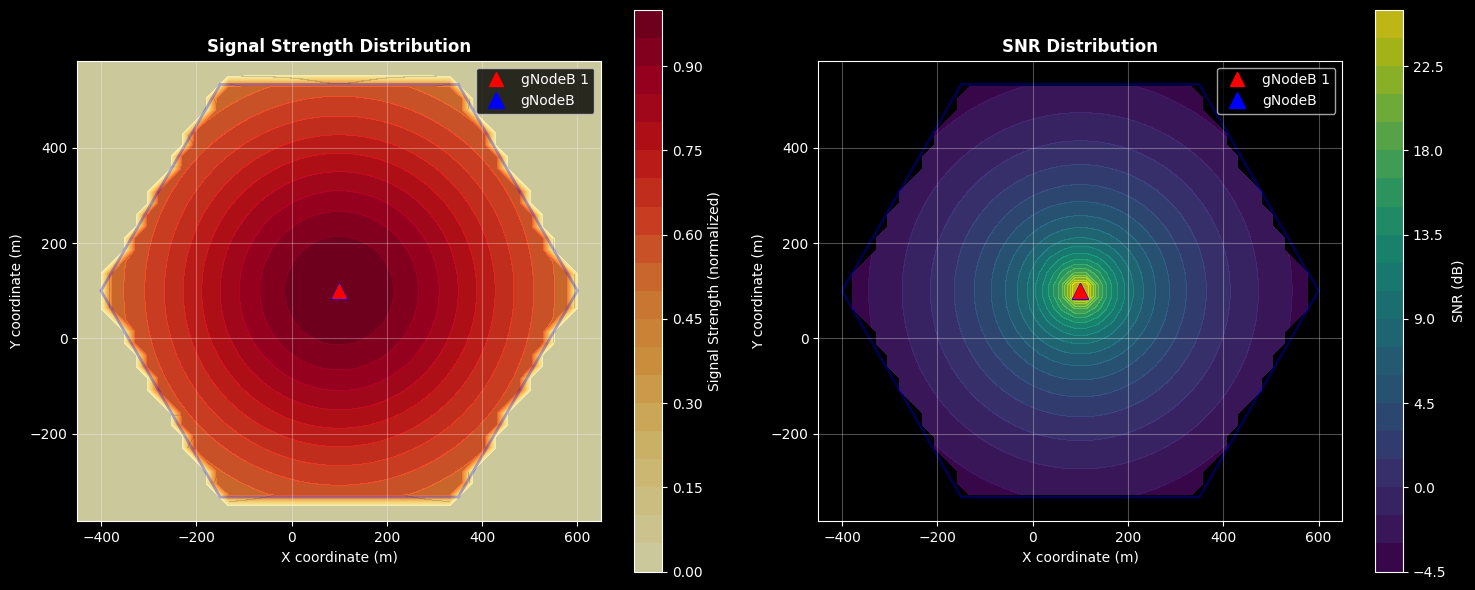


Signal strength at key points:
--------------------------------------------------
Point (100, 100): Distance=0.0m, Signal=1.000, SNR=50.0dB
Point (200, 200): Distance=141.4m, Signal=0.926, SNR=6.9dB
Point (350, 350): Distance=353.6m, Signal=0.667, SNR=-1.0dB
Point (500, 100): Distance=400.0m, Signal=0.610, SNR=-2.1dB


In [11]:
# ============================================
# SECTION 3: Signal Strength and SNR Testing
# ============================================
import numpy as np
print("\n" + "=" * 80)
print("SECTION 3: Signal Strength and SNR Testing")
print("=" * 80)

# Create a grid of points for signal analysis
x_range = np.linspace(gnb.x - gnb.coverage_radius - 100,
                      gnb.x + gnb.coverage_radius + 100, 50)
y_range = np.linspace(gnb.y - gnb.coverage_radius - 100,
                      gnb.y + gnb.coverage_radius + 100, 50)
X, Y = np.meshgrid(x_range, y_range)

# Calculate signal strength and SNR
Z_signal = np.zeros_like(X)
Z_snr = np.zeros_like(X)

for i in range(len(x_range)):
    for j in range(len(y_range)):
        if gnb.is_point_in_coverage(X[j, i], Y[j, i]):
            Z_signal[j, i] = gnb.get_ue_signal_strength(X[j, i], Y[j, i])
            Z_snr[j, i] = gnb.get_ue_snr(X[j, i], Y[j, i])
        else:
            Z_signal[j, i] = 0
            Z_snr[j, i] = -np.inf

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Signal strength heatmap
contour1 = axes[0].contourf(X, Y, Z_signal, levels=20, cmap='YlOrRd', alpha=0.8)
plt.colorbar(contour1, ax=axes[0], label='Signal Strength (normalized)')
gnb.visualize_coverage(ax=axes[0], color='none', edge_color='blue', linewidth=2)
axes[0].plot(gnb.x, gnb.y, 'b^', markersize=12, label='gNodeB')
axes[0].set_title('Signal Strength Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X coordinate (m)')
axes[0].set_ylabel('Y coordinate (m)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# SNR heatmap
masked_snr = np.ma.masked_invalid(Z_snr)
contour2 = axes[1].contourf(X, Y, masked_snr, levels=20, cmap='viridis', alpha=0.8)
plt.colorbar(contour2, ax=axes[1], label='SNR (dB)')
gnb.visualize_coverage(ax=axes[1], color='none', edge_color='blue', linewidth=2)
axes[1].plot(gnb.x, gnb.y, 'b^', markersize=12, label='gNodeB')
axes[1].set_title('SNR Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('X coordinate (m)')
axes[1].set_ylabel('Y coordinate (m)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print sample values
print("\nSignal strength at key points:")
print("-" * 50)
test_points_signal = [(100, 100), (200, 200), (350, 350), (500, 100)]
for x, y in test_points_signal:
    if gnb.is_point_in_coverage(x, y):
        signal = gnb.get_ue_signal_strength(x, y)
        snr = gnb.get_ue_snr(x, y)
        dist = gnb.distance_to_ue(x, y)
        print(f"Point ({x:>3}, {y:>3}): Distance={dist:.1f}m, Signal={signal:.3f}, SNR={snr:.1f}dB")
    else:
        print(f"Point ({x:>3}, {y:>3}): OUT OF COVERAGE")


SECTION 4: Dense Deployment Testing

4.1 Testing Different Deployment Patterns:
------------------------------------------------------------
✓ Using existing slices

4.2 Visualizing Different Deployment Patterns:


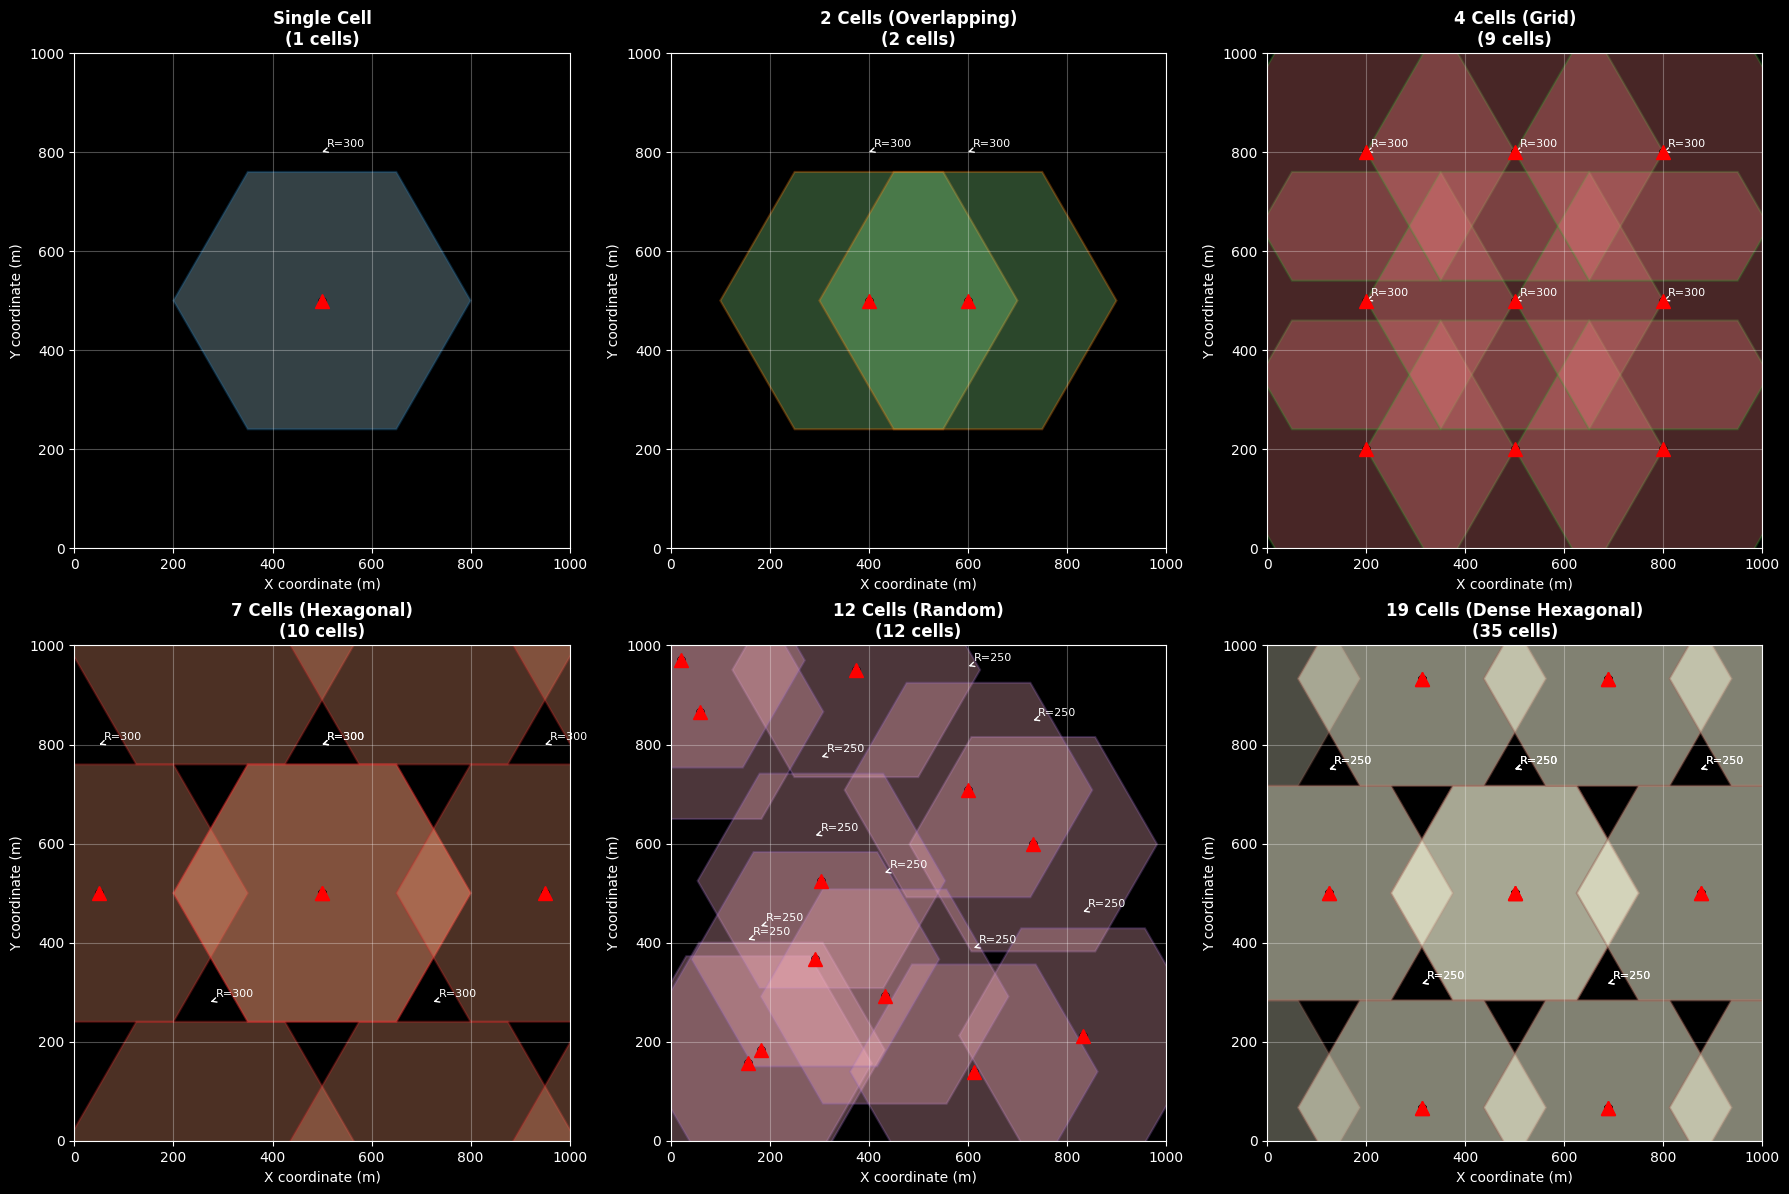


4.3 Coverage Analysis for Dense Deployments:
--------------------------------------------------------------------------------

Analyzing Single Cell...
  Cells: 1
  Coverage: 22.7%
  Overlap: 0.0%
  Avg coverage count: 1.00
  Avg signal strength: 0.726
  Avg SNR: 5.5 dB

Analyzing 2 Cells (Overlapping)...
  Cells: 2
  Coverage: 33.0%
  Overlap: 12.6%
  Avg coverage count: 1.38
  Avg signal strength: 0.747
  Avg SNR: 6.2 dB

Analyzing 4 Cells (Grid)...
  Cells: 9
  Coverage: 99.7%
  Overlap: 64.0%
  Avg coverage count: 1.86
  Avg signal strength: 0.826
  Avg SNR: 8.4 dB

Analyzing 7 Cells (Hexagonal)...
  Cells: 10
  Coverage: 89.7%
  Overlap: 25.8%
  Avg coverage count: 1.33
  Avg signal strength: 0.740
  Avg SNR: 5.9 dB

Analyzing 12 Cells (Random)...
  Cells: 12
  Coverage: 87.4%
  Overlap: 54.6%
  Avg coverage count: 1.83
  Avg signal strength: 0.791
  Avg SNR: 9.1 dB

Analyzing 19 Cells (Dense Hexagonal)...
  Cells: 35
  Coverage: 93.6%
  Overlap: 88.0%
  Avg coverage count: 2.30


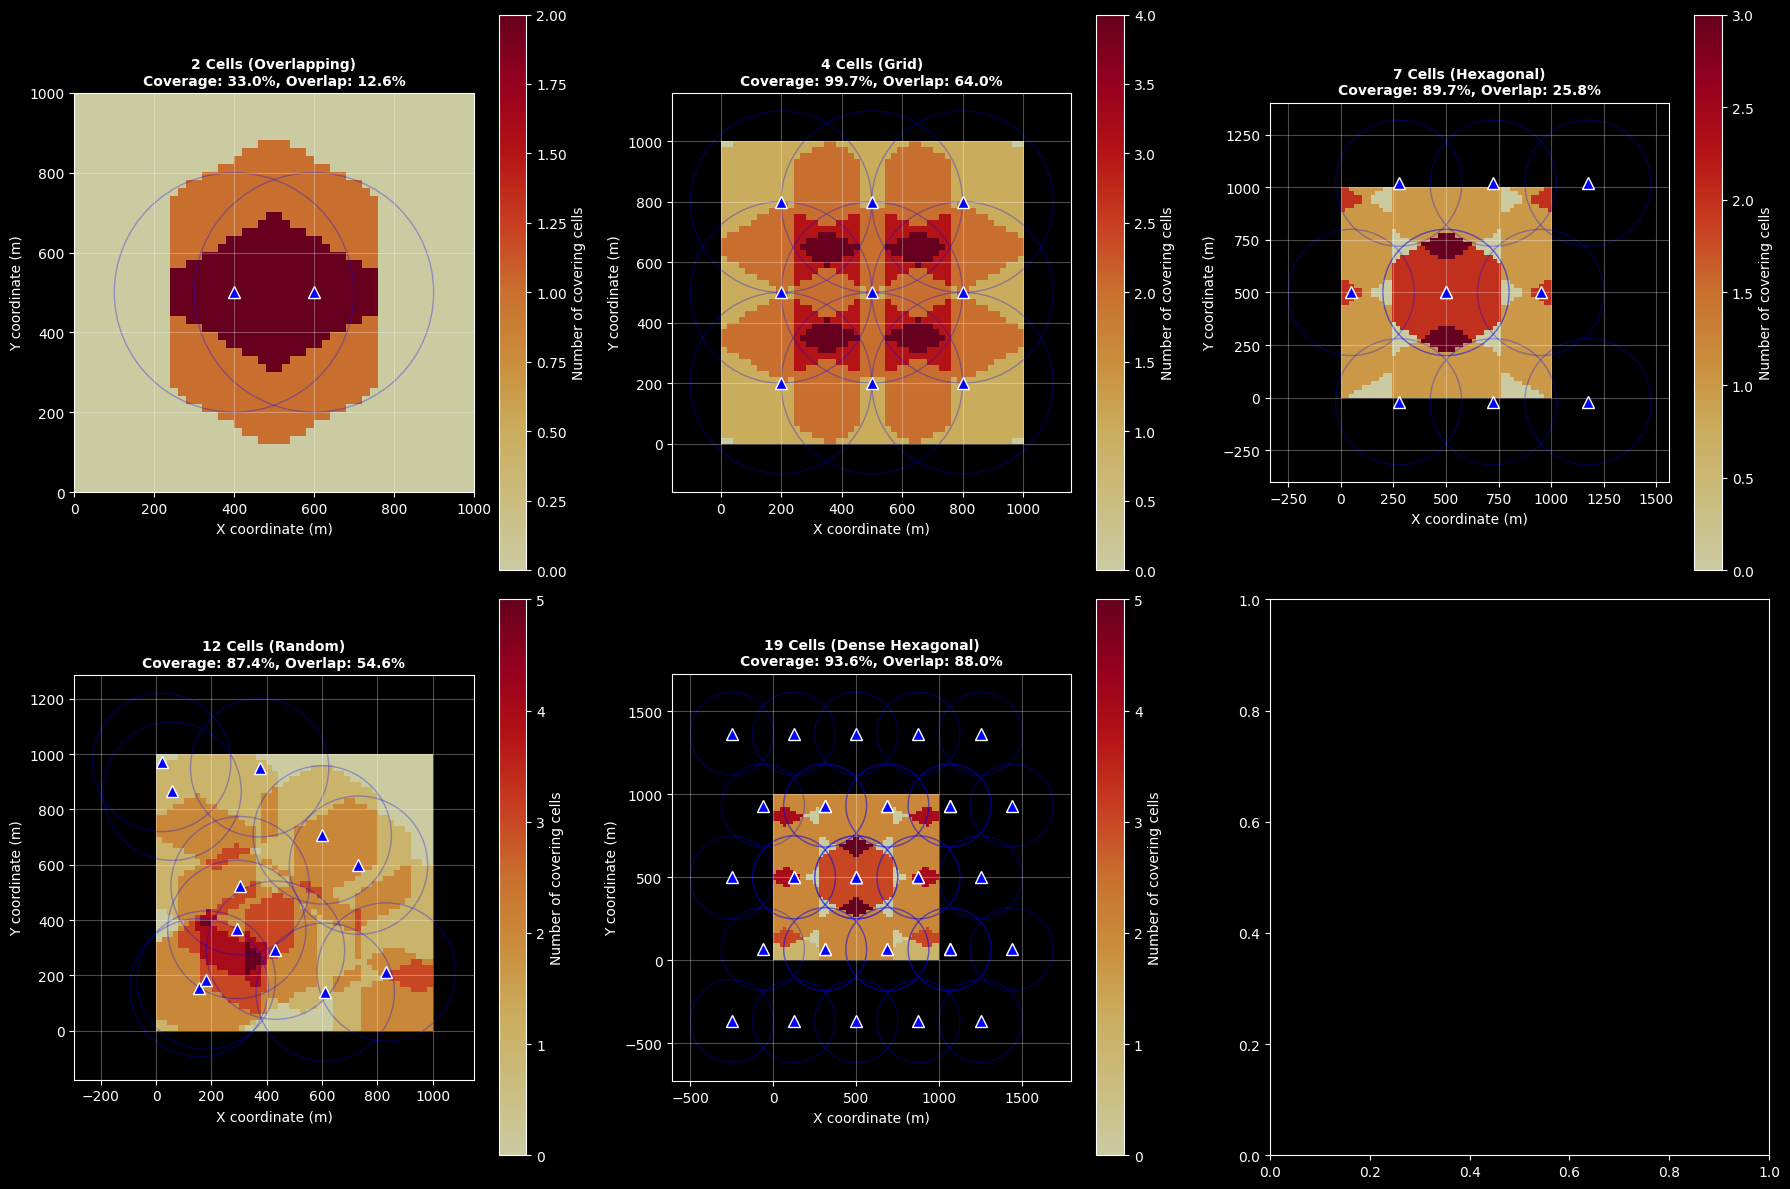


4.5 Best Server Maps (Highest SNR):


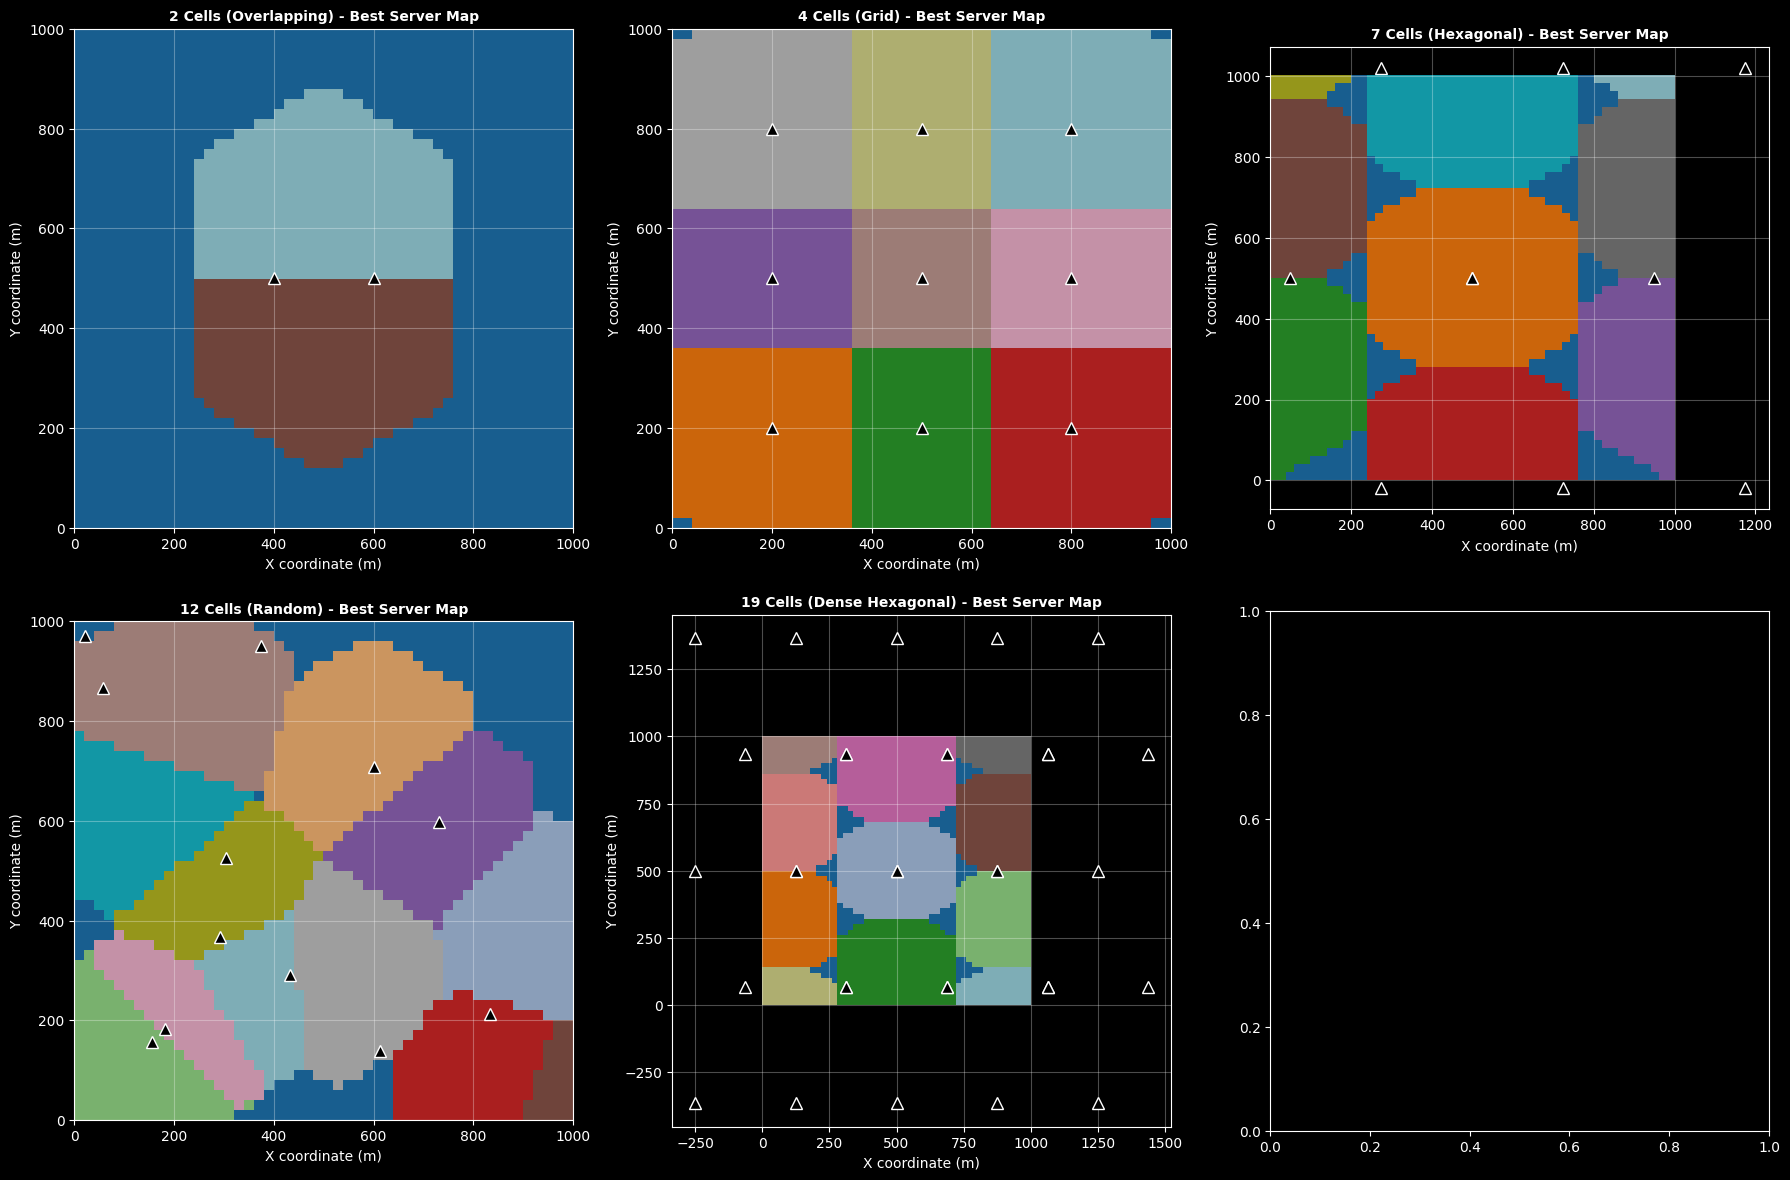


4.6 SNR Distribution Analysis:


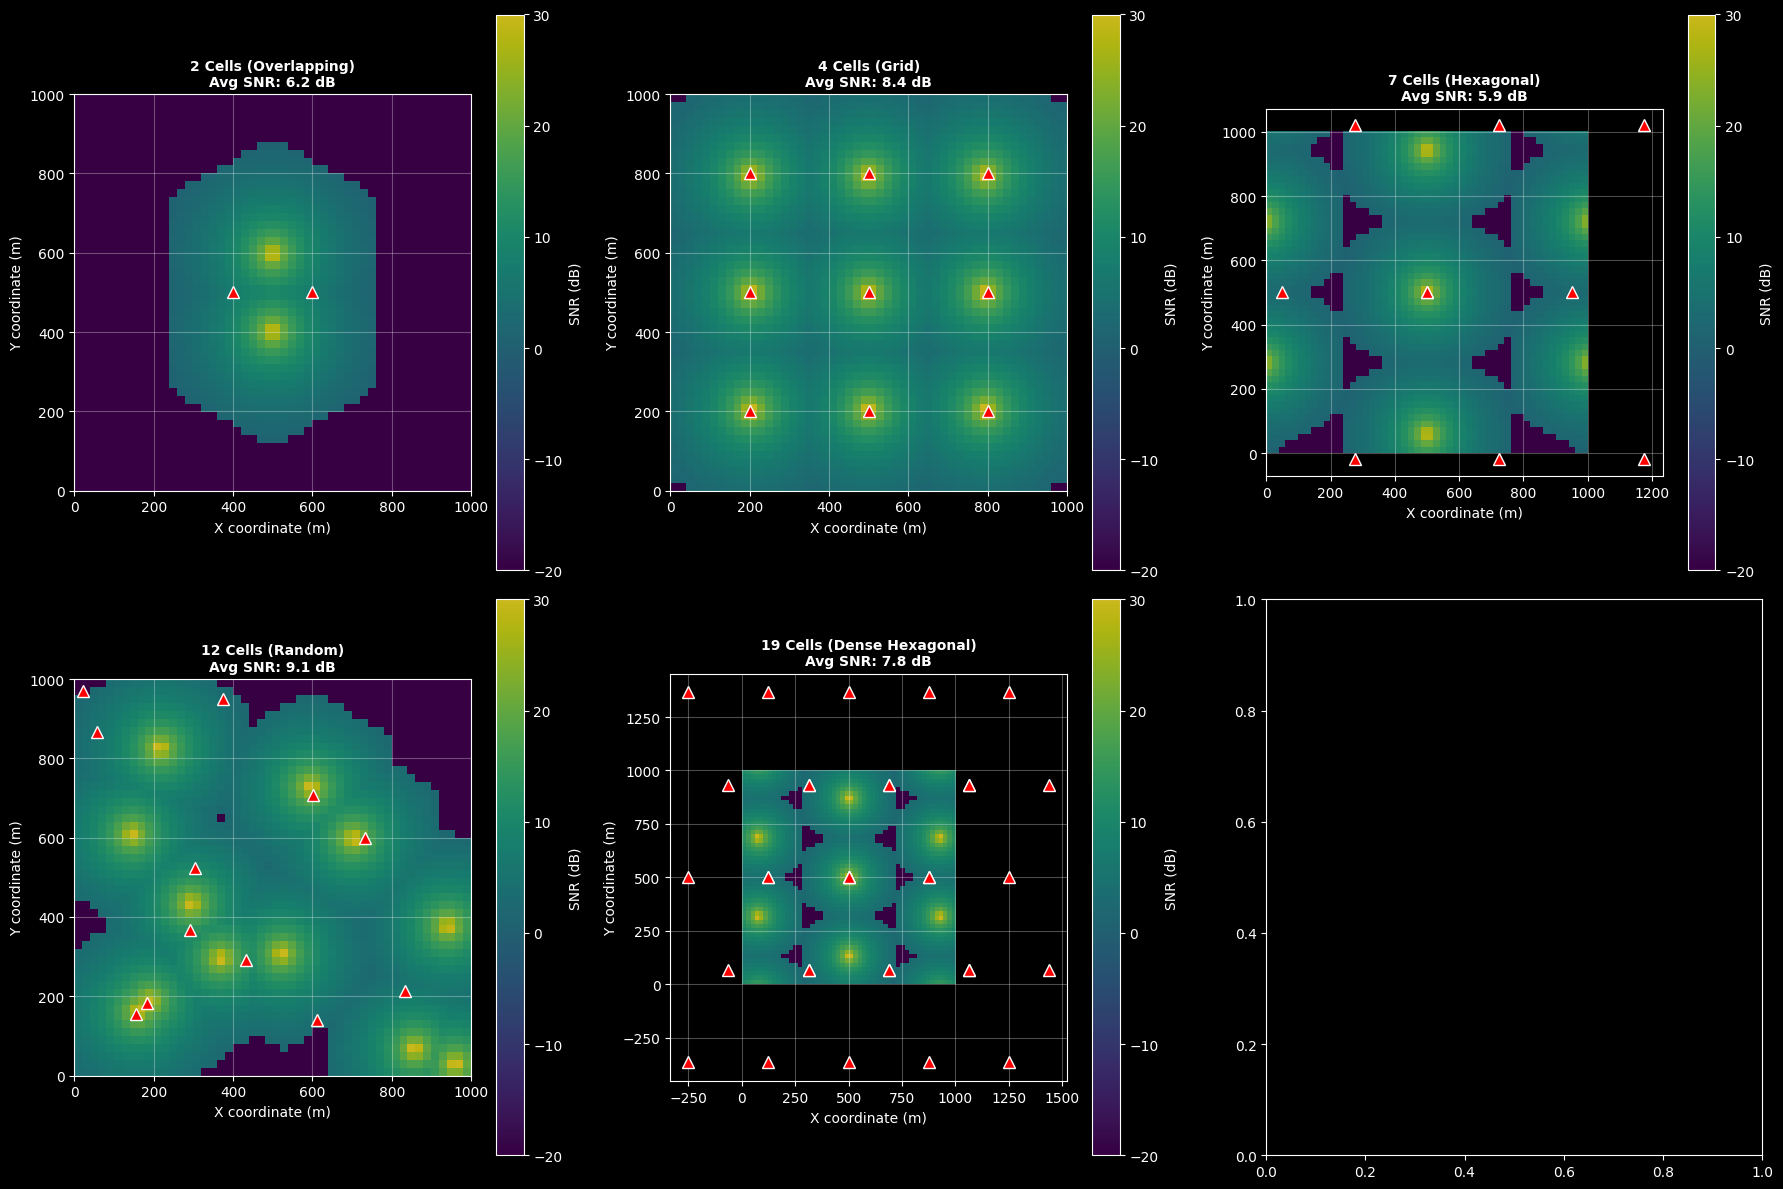


4.7 Performance Metrics Comparison:

Deployment                Cells    Coverage %   Overlap %    Avg Coverage   Avg SNR (dB)
Single Cell               1        22.7         0.0          1.00           5.5         
2 Cells (Overlapping)     2        33.0         12.6         1.38           6.2         
4 Cells (Grid)            9        99.7         64.0         1.86           8.4         
7 Cells (Hexagonal)       10       89.7         25.8         1.33           5.9         
12 Cells (Random)         12       87.4         54.6         1.83           9.1         
19 Cells (Dense Hexagonal) 35       93.6         88.0         2.30           7.8         

4.8 Scalability Analysis - Testing Different Densities:

Running scalability test...
Cells:   1 | Coverage:   7.2% | Overlap:   0.0% | Time: 0.00s
Cells:   6 | Coverage:  38.0% | Overlap:   8.7% | Time: 0.01s
Cells:  11 | Coverage:  70.2% | Overlap:  23.9% | Time: 0.02s
Cells:  16 | Coverage:  75.2% | Overlap:  45.9% | Time: 0.04s
Cell

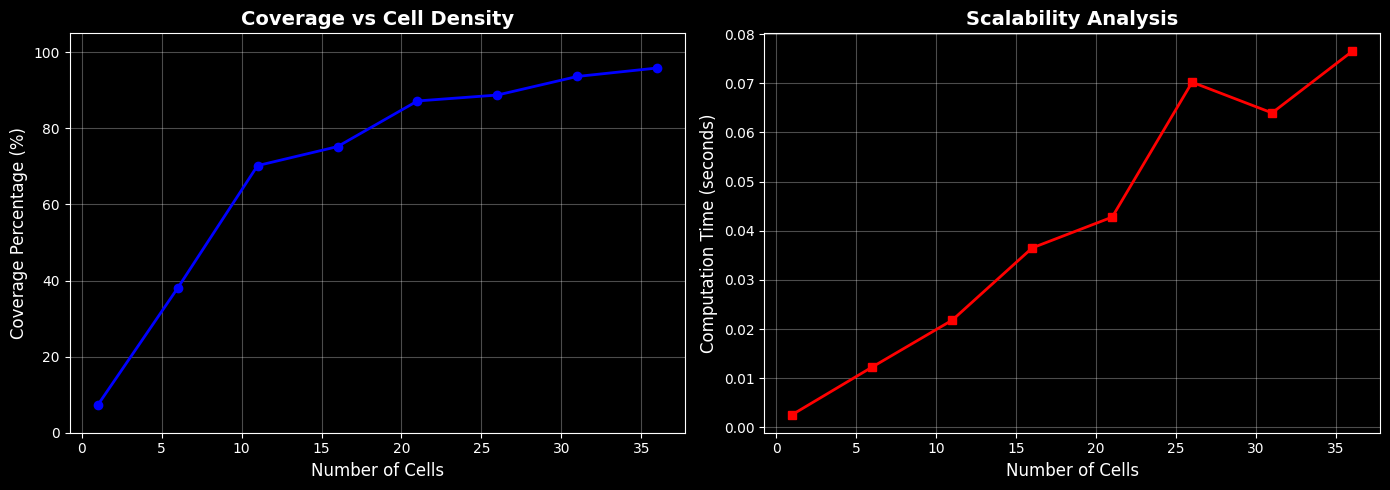


4.9 Interference Analysis for Dense Deployment:


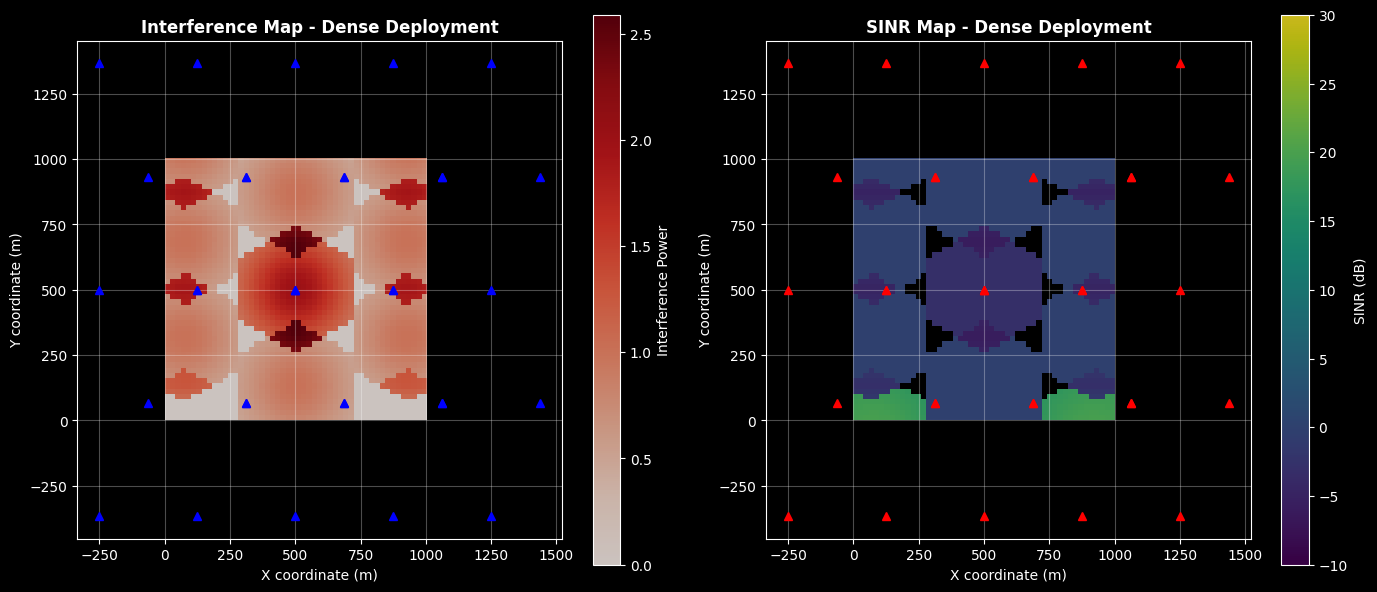


DENSE DEPLOYMENT TESTING - SUMMARY
✓ Tested 6 different deployment patterns
✓ Analyzed coverage for up to 35 cells
✓ Coverage ranges: 22.7% - 99.7%
✓ Overlap ranges: 0.0% - 88.0%
✓ Best SNR achieved: 9.1 dB
✓ Scalability: 8 density levels tested
✓ Interference analysis completed for dense deployment

4.11 All Deployments Comparison:


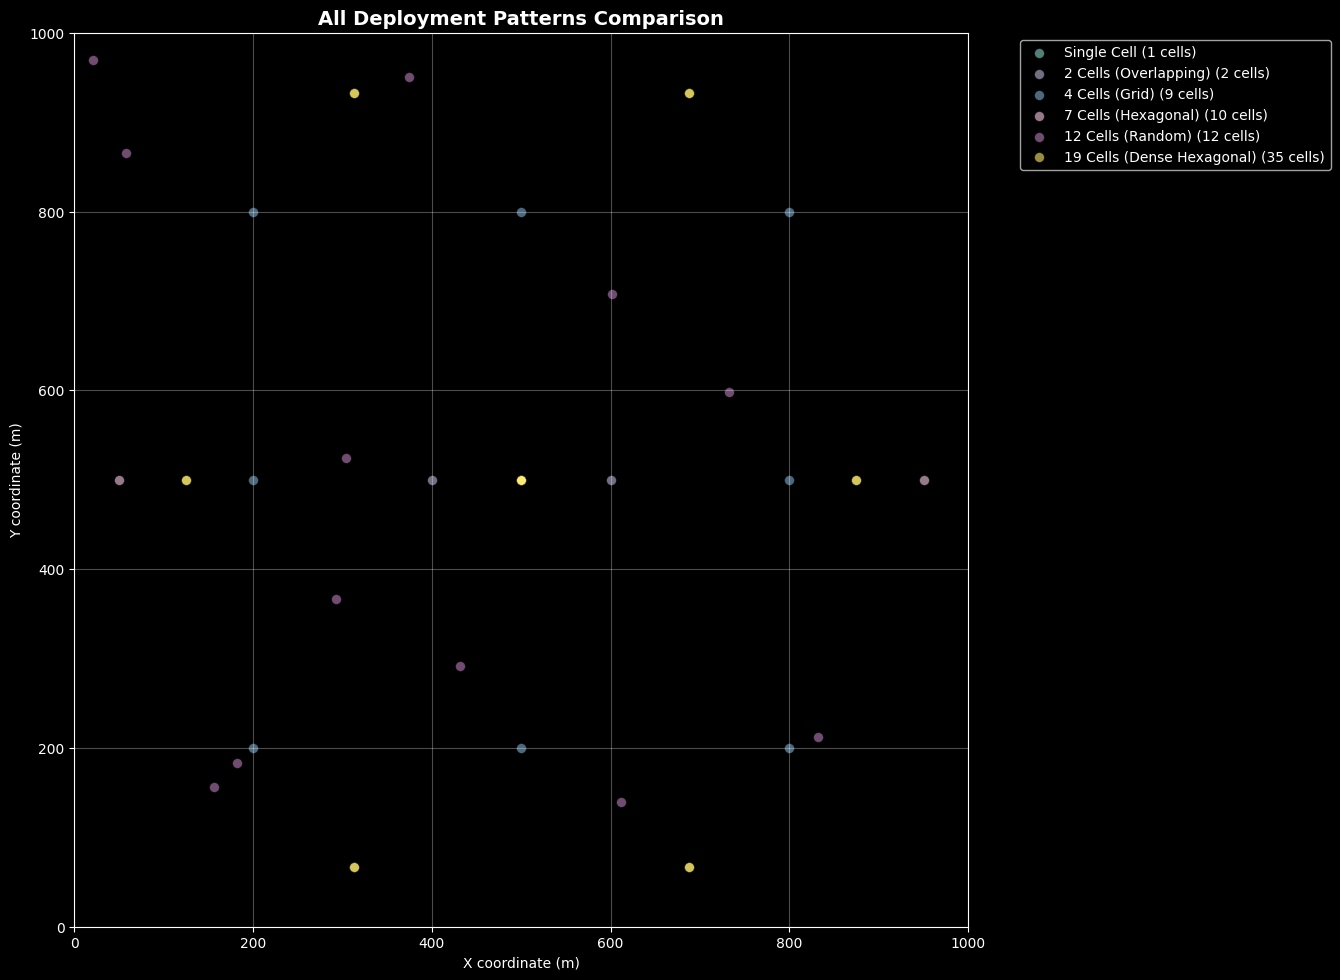


✓ Dense deployment testing completed successfully!


In [17]:
# ============================================
# SECTION 4: Dense Deployment Testing (FIXED)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import time

print("\n" + "=" * 80)
print("SECTION 4: Dense Deployment Testing")
print("=" * 80)

# 4.1: Different Deployment Patterns
print("\n4.1 Testing Different Deployment Patterns:")
print("-" * 60)

def create_hexagonal_grid(center_x, center_y, radius, layers, coverage_radius, slices, slots_per_step=10, n_prbs=50):
    """Create a hexagonal grid of gNodeBs"""
    nodebs = []
    id_counter = 0

    # Hexagonal grid parameters
    dx = coverage_radius * 1.5  # Horizontal spacing
    dy = coverage_radius * np.sqrt(3)  # Vertical spacing

    for layer in range(layers):
        for i in range(-layer, layer + 1):
            for j in range(-layer, layer + 1):
                if abs(i) + abs(j) <= layer * 2:
                    x = center_x + i * dx + (j % 2) * dx/2
                    y = center_y + j * dy

                    # Filter to create hexagonal pattern
                    if abs(i) + abs(j) <= layer * 2:
                        gnb = NodeB(
                            id=id_counter,
                            x=x, y=y,
                            slices_l1=slices,
                            slots_per_step=slots_per_step,
                            n_prbs=n_prbs,
                            coverage_radius=coverage_radius
                        )
                        nodebs.append(gnb)
                        id_counter += 1

    return nodebs

def create_rectangular_grid(x_min, x_max, y_min, y_max, spacing_x, spacing_y, coverage_radius, slices):
    """Create a rectangular grid of gNodeBs"""
    nodebs = []
    id_counter = 0

    x_coords = np.arange(x_min, x_max + spacing_x, spacing_x)
    y_coords = np.arange(y_min, y_max + spacing_y, spacing_y)

    for x in x_coords:
        for y in y_coords:
            gnb = NodeB(
                id=id_counter,
                x=x, y=y,
                slices_l1=slices,
                slots_per_step=10,
                n_prbs=50,
                coverage_radius=coverage_radius
            )
            nodebs.append(gnb)
            id_counter += 1

    return nodebs

def create_random_deployment(area_size, n_cells, coverage_radius, slices, seed=42):
    """Create random deployment of gNodeBs"""
    np.random.seed(seed)
    nodebs = []

    for i in range(n_cells):
        x = np.random.uniform(0, area_size)
        y = np.random.uniform(0, area_size)
        gnb = NodeB(
            id=i,
            x=x, y=y,
            slices_l1=slices,
            slots_per_step=10,
            n_prbs=50,
            coverage_radius=coverage_radius
        )
        nodebs.append(gnb)

    return nodebs

# Create slices for testing (using existing my_slices or create mock)
try:
    test_slices = my_slices
    print("✓ Using existing slices")
except NameError:
    # Create mock slices if not available
    class MockSlice:
        def __init__(self, id):
            self.id = id
        def reset(self): pass
        def reset_info(self): pass
        def slot(self): pass
        def get_state(self): return np.array([0])
        def get_n_variables(self): return 1
        def get_info(self): return {}
        def compute_reward(self): return (1, 0)
        def set_prbs(self, start, count): pass

    test_slices = [MockSlice(0), MockSlice(1)]
    print("✓ Created mock slices for testing")

# Test different deployments
deployments = {
    "Single Cell": [NodeB(id=0, x=500, y=500, slices_l1=test_slices, slots_per_step=10, n_prbs=50, coverage_radius=300)],
    "2 Cells (Overlapping)": [
        NodeB(id=0, x=400, y=500, slices_l1=test_slices, slots_per_step=10, n_prbs=50, coverage_radius=300),
        NodeB(id=1, x=600, y=500, slices_l1=test_slices, slots_per_step=10, n_prbs=50, coverage_radius=300)
    ],
    "4 Cells (Grid)": create_rectangular_grid(200, 800, 200, 800, 300, 300, 300, test_slices),
    "7 Cells (Hexagonal)": create_hexagonal_grid(500, 500, 300, 2, 300, test_slices),
    "12 Cells (Random)": create_random_deployment(1000, 12, 250, test_slices),
    "19 Cells (Dense Hexagonal)": create_hexagonal_grid(500, 500, 250, 3, 250, test_slices)
}

# 4.2: Deployment Visualization (FIXED - using single colors per deployment)
print("\n4.2 Visualizing Different Deployment Patterns:")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Define a color map for different deployments
deployment_colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon',
                      'lightpink', 'lightyellow', 'lightcyan', 'lightgray']

for idx, (deployment_name, nodebs) in enumerate(deployments.items()):
    if idx >= len(axes):
        break

    ax = axes[idx]
    color = deployment_colors[idx % len(deployment_colors)]
    edge_color = plt.cm.tab10(idx % 10)

    for gnb in nodebs:
        gnb.visualize_coverage(ax=ax, color=color, alpha=0.3,
                               edge_color=edge_color, linewidth=1.5)
        ax.plot(gnb.x, gnb.y, 'o', color=edge_color, markersize=6,
                markeredgecolor='black', markeredgewidth=0.5)

    ax.set_title(f'{deployment_name}\n({len(nodebs)} cells)', fontsize=12, fontweight='bold')
    ax.set_xlabel('X coordinate (m)')
    ax.set_ylabel('Y coordinate (m)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlim(0, 1000)
    ax.set_ylim(0, 1000)

plt.tight_layout()
plt.show()

# 4.3: Coverage Analysis for Dense Deployments
print("\n4.3 Coverage Analysis for Dense Deployments:")
print("-" * 80)

def analyze_coverage(nodebs, area_size=1000, resolution=50):
    """Analyze coverage metrics for a deployment"""
    x = np.linspace(0, area_size, resolution)
    y = np.linspace(0, area_size, resolution)
    X, Y = np.meshgrid(x, y)

    coverage_count = np.zeros((resolution, resolution))
    signal_strength = np.zeros((resolution, resolution))
    best_snr = np.full((resolution, resolution), -np.inf)
    best_cell = np.full((resolution, resolution), -1)

    for i in range(resolution):
        for j in range(resolution):
            point_x, point_y = X[i, j], Y[i, j]

            for gnb in nodebs:
                if gnb.is_point_in_coverage(point_x, point_y):
                    coverage_count[i, j] += 1
                    signal = gnb.get_ue_signal_strength(point_x, point_y)
                    snr = gnb.get_ue_snr(point_x, point_y)

                    if snr > best_snr[i, j]:
                        best_snr[i, j] = snr
                        best_cell[i, j] = gnb.id

                    signal_strength[i, j] = max(signal_strength[i, j], signal)

    # Calculate metrics
    total_points = resolution * resolution
    covered_points = np.sum(coverage_count > 0)
    overlap_points = np.sum(coverage_count > 1)
    coverage_percentage = 100 * covered_points / total_points
    overlap_percentage = 100 * overlap_points / total_points
    avg_coverage = np.mean(coverage_count[coverage_count > 0]) if covered_points > 0 else 0
    avg_signal = np.mean(signal_strength[signal_strength > 0]) if covered_points > 0 else 0
    avg_snr = np.mean(best_snr[best_snr > -np.inf]) if covered_points > 0 else 0

    return {
        'n_cells': len(nodebs),
        'coverage_percentage': coverage_percentage,
        'overlap_percentage': overlap_percentage,
        'avg_coverage_count': avg_coverage,
        'avg_signal': avg_signal,
        'avg_snr': avg_snr,
        'coverage_count': coverage_count,
        'best_cell': best_cell,
        'best_snr': best_snr
    }

# Analyze all deployments
deployment_metrics = {}
for name, nodebs in deployments.items():
    print(f"\nAnalyzing {name}...")
    metrics = analyze_coverage(nodebs)
    deployment_metrics[name] = metrics

    print(f"  Cells: {metrics['n_cells']}")
    print(f"  Coverage: {metrics['coverage_percentage']:.1f}%")
    print(f"  Overlap: {metrics['overlap_percentage']:.1f}%")
    print(f"  Avg coverage count: {metrics['avg_coverage_count']:.2f}")
    print(f"  Avg signal strength: {metrics['avg_signal']:.3f}")
    print(f"  Avg SNR: {metrics['avg_snr']:.1f} dB")

# 4.4: Coverage Heatmaps for Dense Deployments
print("\n4.4 Coverage Heatmaps for Selected Deployments:")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

selected_deployments = ['2 Cells (Overlapping)', '4 Cells (Grid)',
                        '7 Cells (Hexagonal)', '12 Cells (Random)',
                        '19 Cells (Dense Hexagonal)']

for idx, name in enumerate(selected_deployments):
    if idx >= len(axes):
        break

    ax = axes[idx]
    metrics = deployment_metrics[name]

    # Create coverage heatmap
    im = ax.imshow(metrics['coverage_count'].T, origin='lower',
                   extent=[0, 1000, 0, 1000], cmap='YlOrRd', alpha=0.8)
    plt.colorbar(im, ax=ax, label='Number of covering cells')

    # Plot cell centers
    nodebs = deployments[name]
    for gnb in nodebs:
        ax.plot(gnb.x, gnb.y, 'b^', markersize=8, markeredgecolor='white')
        # Add cell radius circle
        circle = Circle((gnb.x, gnb.y), gnb.coverage_radius,
                        fill=False, color='blue', alpha=0.3, linewidth=1)
        ax.add_patch(circle)

    ax.set_title(f'{name}\nCoverage: {metrics["coverage_percentage"]:.1f}%, '
                 f'Overlap: {metrics["overlap_percentage"]:.1f}%',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('X coordinate (m)')
    ax.set_ylabel('Y coordinate (m)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4.5: Best Server Map (Voronoi-like)
print("\n4.5 Best Server Maps (Highest SNR):")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, name in enumerate(selected_deployments[:6]):
    if idx >= len(axes):
        break

    ax = axes[idx]
    metrics = deployment_metrics[name]

    # Create best server map
    im = ax.imshow(metrics['best_cell'].T, origin='lower',
                   extent=[0, 1000, 0, 1000],
                   cmap='tab20', alpha=0.8, interpolation='nearest')

    # Plot cell centers
    nodebs = deployments[name]
    for gnb in nodebs:
        ax.plot(gnb.x, gnb.y, 'k^', markersize=8, markeredgecolor='white')

    ax.set_title(f'{name} - Best Server Map', fontsize=10, fontweight='bold')
    ax.set_xlabel('X coordinate (m)')
    ax.set_ylabel('Y coordinate (m)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4.6: SNR Distribution Analysis
print("\n4.6 SNR Distribution Analysis:")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, name in enumerate(selected_deployments[:6]):
    if idx >= len(axes):
        break

    ax = axes[idx]
    metrics = deployment_metrics[name]

    # Create SNR heatmap
    snr_data = metrics['best_snr'].copy()
    snr_data[snr_data == -np.inf] = -30  # Set out-of-coverage to -30dB

    im = ax.imshow(snr_data.T, origin='lower',
                   extent=[0, 1000, 0, 1000],
                   cmap='viridis', vmin=-20, vmax=30, alpha=0.8)
    plt.colorbar(im, ax=ax, label='SNR (dB)')

    # Plot cell centers
    nodebs = deployments[name]
    for gnb in nodebs:
        ax.plot(gnb.x, gnb.y, 'r^', markersize=8, markeredgecolor='white')

    ax.set_title(f'{name}\nAvg SNR: {metrics["avg_snr"]:.1f} dB',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('X coordinate (m)')
    ax.set_ylabel('Y coordinate (m)')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4.7: Performance Metrics Comparison
print("\n4.7 Performance Metrics Comparison:")

metrics_comparison = []
for name, metrics in deployment_metrics.items():
    metrics_comparison.append({
        'Deployment': name,
        'Cells': metrics['n_cells'],
        'Coverage %': metrics['coverage_percentage'],
        'Overlap %': metrics['overlap_percentage'],
        'Avg Coverage': metrics['avg_coverage_count'],
        'Avg SNR (dB)': metrics['avg_snr']
    })

# Create comparison table
print("\n" + "=" * 100)
print(f"{'Deployment':<25} {'Cells':<8} {'Coverage %':<12} {'Overlap %':<12} {'Avg Coverage':<14} {'Avg SNR (dB)':<12}")
print("=" * 100)
for m in metrics_comparison:
    print(f"{m['Deployment']:<25} {m['Cells']:<8} {m['Coverage %']:<12.1f} {m['Overlap %']:<12.1f} "
          f"{m['Avg Coverage']:<14.2f} {m['Avg SNR (dB)']:<12.1f}")
print("=" * 100)

# 4.8: Scalability Analysis
print("\n4.8 Scalability Analysis - Testing Different Densities:")

def test_scalability(max_cells=50, area_size=1000):
    """Test performance with increasing number of cells"""
    densities = list(range(1, max_cells + 1, 5))
    coverage_results = []
    computation_times = []

    for n_cells in densities:
        # Create random deployment
        nodebs = create_random_deployment(area_size, n_cells, 200, test_slices)

        # Measure computation time for coverage analysis
        start_time = time.time()
        metrics = analyze_coverage(nodebs, area_size, resolution=30)  # Lower resolution for speed
        computation_time = time.time() - start_time

        coverage_results.append(metrics['coverage_percentage'])
        computation_times.append(computation_time)

        print(f"Cells: {n_cells:3d} | Coverage: {metrics['coverage_percentage']:5.1f}% | "
              f"Overlap: {metrics['overlap_percentage']:5.1f}% | Time: {computation_time:.2f}s")

    return densities, coverage_results, computation_times

# Run scalability test
print("\nRunning scalability test...")
densities, coverage_results, computation_times = test_scalability(max_cells=40, area_size=1000)

# Plot scalability results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(densities, coverage_results, 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Number of Cells', fontsize=12)
ax1.set_ylabel('Coverage Percentage (%)', fontsize=12)
ax1.set_title('Coverage vs Cell Density', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)

ax2.plot(densities, computation_times, 'r-s', linewidth=2, markersize=6)
ax2.set_xlabel('Number of Cells', fontsize=12)
ax2.set_ylabel('Computation Time (seconds)', fontsize=12)
ax2.set_title('Scalability Analysis', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4.9: Interference Analysis
print("\n4.9 Interference Analysis for Dense Deployment:")

def analyze_interference(nodebs, area_size=1000, resolution=50):
    """Analyze interference levels in the network"""
    x = np.linspace(0, area_size, resolution)
    y = np.linspace(0, area_size, resolution)
    X, Y = np.meshgrid(x, y)

    interference = np.zeros((resolution, resolution))
    sinr = np.zeros((resolution, resolution))

    for i in range(resolution):
        for j in range(resolution):
            point_x, point_y = X[i, j], Y[i, j]

            # Find best server and collect all signals
            signals = []
            for gnb in nodebs:
                if gnb.is_point_in_coverage(point_x, point_y):
                    signal = gnb.get_ue_signal_strength(point_x, point_y)
                    signals.append((gnb.id, signal))

            if signals:
                # Sort by signal strength
                signals.sort(key=lambda x: x[1], reverse=True)
                best_signal = signals[0][1]
                interference_power = sum(s[1] for s in signals[1:])
                interference[i, j] = interference_power

                # Calculate SINR (assuming noise = 0.01)
                noise = 0.01
                sinr[i, j] = 10 * np.log10(best_signal / (interference_power + noise))
            else:
                interference[i, j] = 0
                sinr[i, j] = -np.inf

    return interference, sinr

# Analyze interference for dense hexagonal deployment
dense_hex = deployments['19 Cells (Dense Hexagonal)']
interference, sinr = analyze_interference(dense_hex)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Interference map
im1 = ax1.imshow(interference.T, origin='lower', extent=[0, 1000, 0, 1000],
                 cmap='Reds', alpha=0.8)
plt.colorbar(im1, ax=ax1, label='Interference Power')
for gnb in dense_hex:
    ax1.plot(gnb.x, gnb.y, 'b^', markersize=6)
ax1.set_title('Interference Map - Dense Deployment', fontsize=12, fontweight='bold')
ax1.set_xlabel('X coordinate (m)')
ax1.set_ylabel('Y coordinate (m)')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# SINR map
sinr_masked = np.ma.masked_invalid(sinr)
im2 = ax2.imshow(sinr_masked.T, origin='lower', extent=[0, 1000, 0, 1000],
                 cmap='viridis', vmin=-10, vmax=30, alpha=0.8)
plt.colorbar(im2, ax=ax2, label='SINR (dB)')
for gnb in dense_hex:
    ax2.plot(gnb.x, gnb.y, 'r^', markersize=6)
ax2.set_title('SINR Map - Dense Deployment', fontsize=12, fontweight='bold')
ax2.set_xlabel('X coordinate (m)')
ax2.set_ylabel('Y coordinate (m)')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4.10: Summary Statistics
print("\n" + "=" * 80)
print("DENSE DEPLOYMENT TESTING - SUMMARY")
print("=" * 80)
print(f"✓ Tested {len(deployments)} different deployment patterns")
print(f"✓ Analyzed coverage for up to {max([len(d) for d in deployments.values()])} cells")
print(f"✓ Coverage ranges: {min([m['coverage_percentage'] for m in deployment_metrics.values()]):.1f}% - "
      f"{max([m['coverage_percentage'] for m in deployment_metrics.values()]):.1f}%")
print(f"✓ Overlap ranges: {min([m['overlap_percentage'] for m in deployment_metrics.values()]):.1f}% - "
      f"{max([m['overlap_percentage'] for m in deployment_metrics.values()]):.1f}%")
print(f"✓ Best SNR achieved: {max([m['avg_snr'] for m in deployment_metrics.values()]):.1f} dB")
print(f"✓ Scalability: {len(densities)} density levels tested")
print(f"✓ Interference analysis completed for dense deployment")
print("=" * 80)

# 4.11: Comparison Visualization
print("\n4.11 All Deployments Comparison:")

# Create a comparison of all deployment types
fig, ax = plt.subplots(figsize=(12, 10))

colors = plt.cm.Set3(np.linspace(0, 1, len(deployments)))
for idx, (name, nodebs) in enumerate(deployments.items()):
    # Plot only cell centers for comparison
    x_coords = [gnb.x for gnb in nodebs]
    y_coords = [gnb.y for gnb in nodebs]
    ax.scatter(x_coords, y_coords, c=[colors[idx]], label=f'{name} ({len(nodebs)} cells)',
               s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

ax.set_title('All Deployment Patterns Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('X coordinate (m)')
ax.set_ylabel('Y coordinate (m)')
ax.set_xlim(0, 1000)
ax.set_ylim(0, 1000)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n✓ Dense deployment testing completed successfully!")